In [1]:
import sys
sys.path.insert(0, "../..")

from src.models        import build_logdeeponet
from src.data          import ODEIterableDataset, DirichletSampler, ConstrainedLHCSampler
from src.physics       import Robertson, ODEsolver
from src.training      import Trainer, build_dataloaders

import numpy as np
import matplotlib.pyplot as plt 
import torch
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Initialize Roberston Model
k1 = 4e-2
k2 = 3e7
k3 = 1e4
system = Robertson([k1, k2, k3])

# Initialize Sampler Object 
sampler = ConstrainedLHCSampler(low=0.80, high=1.0)

In [3]:
dataset_size = 1000
batch_size   = 1
num_workers  = 2
t_final      = 1e6
t_span       = (1e-4, t_final)

rob_dataset = ODEIterableDataset(size          = dataset_size,
                                 system_class  = system,
                                 sampler       = sampler,
                                 t_span        = t_span,
                                 log_sampling  = False,
                                 full_solution = True,
                                 method        = "BDF")

rob_loader  = DataLoader(dataset     = rob_dataset,
                         batch_size  = batch_size,
                         num_workers = num_workers)

In [4]:
# Set Up DeepONet configuration 

# deep onet 3
"""DEEPONET_CONFIG = {
    
    "hidden_size" : 128,
    "depth"       : 4,
    "latent_size" : 120,
    "input_size_b": 3,
    "input_size_t": 1,
    "output_size" : 3,
    "activation"  : "gelu",
    "t_span"      : t_span

}"""

DEEPONET_CONFIG = {
    
    "hidden_size" : 64,
    "depth"       : 4,
    "latent_size" : 60,
    "input_size_b": 3,
    "input_size_t": 1,
    "output_size" : 3,
    "activation"  : "gelu",
    "t_span"      : t_span

}


# Initialize DeepONet network
 
deeponet = build_logdeeponet(DEEPONET_CONFIG).to(device)
deeponet.load_state_dict(torch.load("../../weights/best_robertson_4.pth", map_location=device))
deeponet.eval()

_ = 0

In [5]:
from src.benchmark import trajectory 

t, sol, pred = trajectory(deeponet, rob_loader, device)

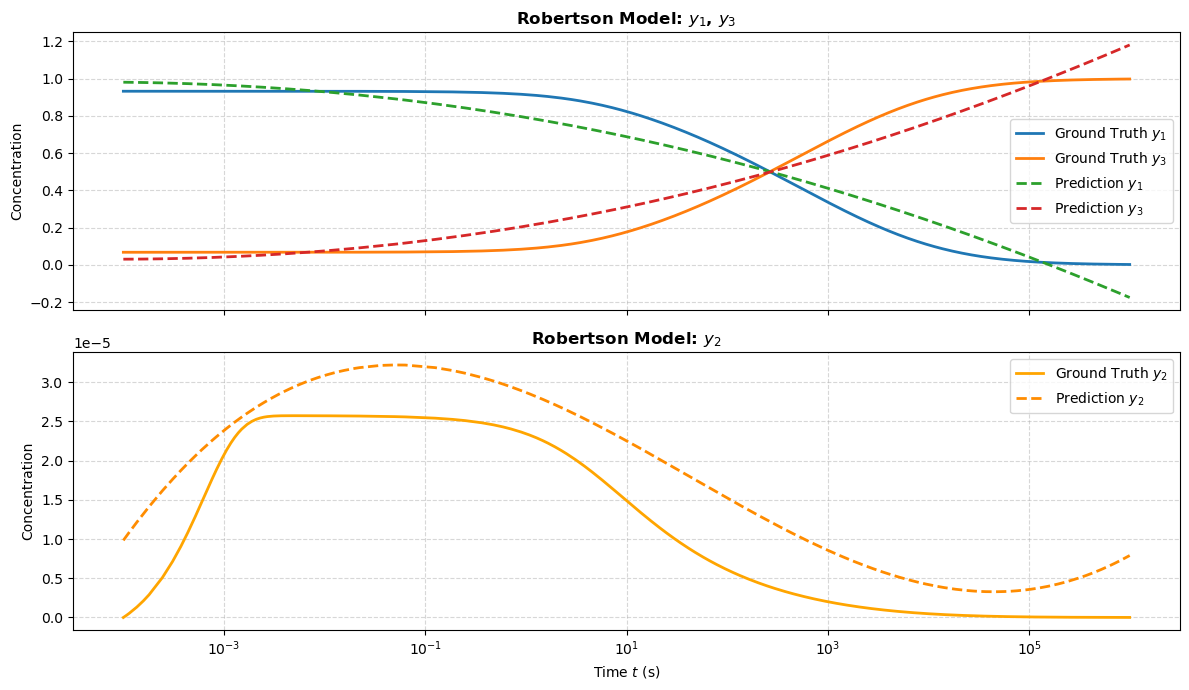

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# --- Top plot: y1, y3 ---
ax1.plot(t, sol[0], lw=2, label="Ground Truth $y_1$")
ax1.plot(t, sol[2], lw=2, label="Ground Truth $y_3$")
ax1.plot(t, pred[:, 0], lw=2, linestyle="--", label="Prediction $y_1$")
ax1.plot(t, pred[:, 2], lw=2, linestyle="--", label="Prediction $y_3$")
ax1.set_xscale('log')
ax1.set_ylabel("Concentration")
ax1.set_title("Robertson Model: $y_1$, $y_3$", fontweight="bold")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Bottom plot: y2 ---
ax2.plot(t, sol[1], lw=2, label="Ground Truth $y_2$", color='orange')
ax2.plot(t, pred[:, 1], lw=2, linestyle="--", label="Prediction $y_2$", color='darkorange')
ax2.set_xscale('log')
ax2.set_xlabel("Time $t$ (s)")
ax2.set_ylabel("Concentration")
ax2.set_title("Robertson Model: $y_2$", fontweight="bold")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [12]:
from src.benchmark import timing_data

num_boxes   = 10
num_samples = 100
t_final     = 1e6

solver = ODEsolver(system).solve

nn_timing, solver_timing = timing_data(model       = deeponet, 
                                       ODEsolver   = solver, 
                                       sampler     = sampler,
                                       t_final     = t_final, 
                                       num_samples = num_samples,
                                       num_boxes   = num_boxes, 
                                       method      = "BDF",
                                       device      = device)

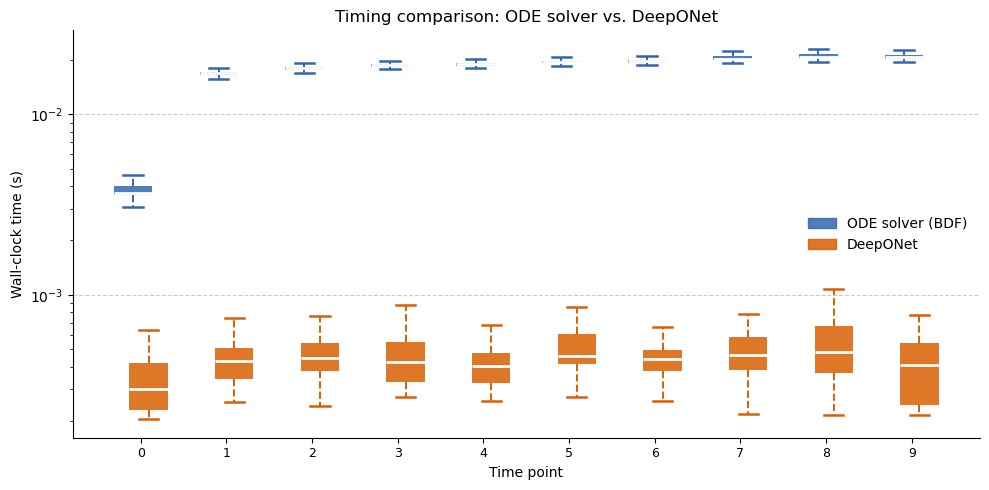

In [26]:
import matplotlib.patches as mpatches

SOLVER_COLOR = "#3266ad"
NN_COLOR     = "#d95f02"
pos          = np.linspace(0, t_final, num_boxes)

plt.figure(figsize=(10, 5))

plt.boxplot(solver_timing,
            positions    = pos - 0.1e5,
            widths       = 0.5e5,
            patch_artist = True,
            showfliers   = False,
            medianprops  = dict(color="white", linewidth=2),
            boxprops     = dict(facecolor=SOLVER_COLOR, alpha=0.85, linewidth=0),
            whiskerprops = dict(color=SOLVER_COLOR, linewidth=1.4, linestyle="--"),
            capprops     = dict(color=SOLVER_COLOR, linewidth=1.8))

plt.boxplot(nn_timing,
            positions    = pos + 0.1e5,
            widths       = 0.5e5,
            patch_artist = True,
            showfliers   = False,
            medianprops  = dict(color="white", linewidth=2),
            boxprops     = dict(facecolor=NN_COLOR, alpha=0.85, linewidth=0),
            whiskerprops = dict(color=NN_COLOR, linewidth=1.4, linestyle="--"),
            capprops     = dict(color=NN_COLOR, linewidth=1.8))

plt.xticks(pos, labels=np.arange(num_boxes), fontsize=9)
plt.yscale("log")
plt.xlabel("Time point")
plt.ylabel("Wall-clock time (s)")
plt.title("Timing comparison: ODE solver vs. DeepONet")

plt.gca().yaxis.grid(True, linestyle="--", alpha=0.4, color="gray")
plt.gca().set_axisbelow(True)
plt.gca().spines[["top", "right"]].set_visible(False)

solver_patch = mpatches.Patch(color=SOLVER_COLOR, alpha=0.85, label="ODE solver (BDF)")
nn_patch     = mpatches.Patch(color=NN_COLOR,     alpha=0.85, label="DeepONet")
plt.legend(handles=[solver_patch, nn_patch], frameon=False, fontsize=10)

plt.tight_layout()
plt.show()